In [11]:
# ===========================================================
# COMPARE ADVANCED MODELS (ATT-CNN-LSTM vs TRANSFORMER)
# Embedding: 768-dim  |  Task: OHLCV Prediction (Week 4)
# ===========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.decomposition import PCA


In [12]:

# === 1. Load metrics from logs or manual entry ===
metrics = pd.DataFrame([
    {"model": "ATT-CNN-LSTM", "mse": 293.96, "mae": 14.12, "epochs": 10},
    {"model": "Transformer", "mse": 327.80, "mae": 14.86, "epochs": 20},
])

display(metrics)


,model,mse,mae,epochs
0,ATT-CNN-LSTM,293.96,14.12,10
1,Transformer,327.80,14.86,20


In [13]:

# === 2. Load embeddings (768-dim) ===
emb_att = np.load("../results/lstm_advanced/att_cnn_lstm_embeddings.npy")
emb_trf = np.load("../results/lstm_advanced/transformer_embeddings.npy")

print(f"ATT-CNN-LSTM embedding: {emb_att.shape}")
print(f"Transformer embedding:  {emb_trf.shape}")


ATT-CNN-LSTM embedding: (2059, 2304)
Transformer embedding:  (2059, 1536)


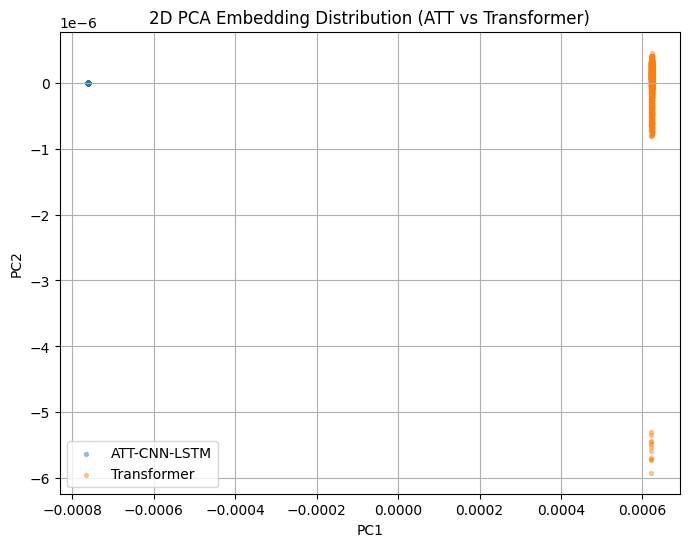

In [14]:

# === 3. PCA reduction for 2D visualization ===
pca = PCA(n_components=2, random_state=42)
att_2d = pca.fit_transform(emb_att)
trf_2d = pca.fit_transform(emb_trf)

plt.figure(figsize=(8,6))
plt.scatter(att_2d[:,0], att_2d[:,1], s=8, alpha=0.4, label="ATT-CNN-LSTM")
plt.scatter(trf_2d[:,0], trf_2d[:,1], s=8, alpha=0.4, label="Transformer")
plt.legend()
plt.title("2D PCA Embedding Distribution (ATT vs Transformer)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.grid(True)
plt.show()


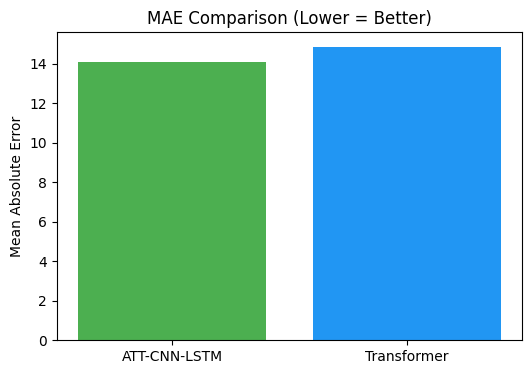

In [15]:


# === 5. Plot summary comparison ===
plt.figure(figsize=(6,4))
plt.bar(metrics["model"], metrics["mae"], color=["#4CAF50", "#2196F3"])
plt.title("MAE Comparison (Lower = Better)")
plt.ylabel("Mean Absolute Error")
plt.show()
